## Imports

In [ ]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

from old_neuro_fuzzy_toolbox import h_ANFIS, Gaussian_MF, EarlyStopping, get_measures, Basic_optimizer_training_algorithm

In [11]:
import numpy as np

In [12]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Binary Classification

## Data

In [13]:
from ucimlrepo import fetch_ucirepo

In [14]:
parkinsons = fetch_ucirepo(id=174)

X = parkinsons.data.features
y = parkinsons.data.targets

In [15]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [16]:
unique_classes, counts = np.unique(y_train.values, return_counts=True)
print(unique_classes)
print(counts)

[0 1]
[ 33 103]


In [17]:
unique_classes, counts = np.unique(y_test.values, return_counts=True)
print(unique_classes)
print(counts)

[0 1]
[15 44]


In [18]:
scaler = MinMaxScaler(feature_range=(-1, 1))

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [19]:
x_train = torch.from_numpy(x_train)
x_test = torch.from_numpy(x_test)
y_train = torch.from_numpy(y_train.values).squeeze()
y_test = torch.from_numpy(y_test.values).squeeze()

In [20]:
train_loader = data.DataLoader(
    data.TensorDataset(
        x_train, 
        y_train), 
    batch_size = 4, 
    shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

## Model & Training

In [91]:
model = h_ANFIS(
    input_size = 22,
    num_mfs = 7,
    outputs = 2,
    rule_reduced = True,
    output_type='multiclass',
    dtype=torch.float64
)

#model.init_premises(x_train)

#model.init_consequents(x_train, y_train)

In [ ]:
epochs=1000

loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}
#optimizer = torch.optim.Adam
#params = {'lr': 0.005}
#optimizer = torch.optim.SGD
#params = {'lr': 0.001, 'momentum': 0.9}

validation=0.3

early_stopping = EarlyStopping(
    patience=30, 
    delta=0.0001
)

In [93]:
trainer = Basic_optimizer_training_algorithm(
    epochs=epochs,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=validation,
    early_stopping=early_stopping
)

In [94]:
trainer(model, train_loader, verbose=True)

Epoch:    1/1000 - loss: 1.561909 - validation loss: 2.039170
Epoch:    2/1000 - loss: 1.546049 - validation loss: 2.014902
Epoch:    3/1000 - loss: 1.527665 - validation loss: 1.978442
Epoch:    4/1000 - loss: 1.513837 - validation loss: 1.951542
Epoch:    5/1000 - loss: 1.498215 - validation loss: 1.915346
Epoch:    6/1000 - loss: 1.478789 - validation loss: 1.869795
Epoch:    7/1000 - loss: 1.463689 - validation loss: 1.834924
Epoch:    8/1000 - loss: 1.445470 - validation loss: 1.788261
Epoch:    9/1000 - loss: 1.423200 - validation loss: 1.732291
Epoch:   10/1000 - loss: 1.394050 - validation loss: 1.661575
Epoch:   11/1000 - loss: 1.359129 - validation loss: 1.588187
Epoch:   12/1000 - loss: 1.301226 - validation loss: 1.491264
Epoch:   13/1000 - loss: 1.186242 - validation loss: 1.349412
Epoch:   14/1000 - loss: 0.981170 - validation loss: 1.149644
Epoch:   15/1000 - loss: 0.761905 - validation loss: 0.916596
Epoch:   16/1000 - loss: 0.670343 - validation loss: 0.790872
Epoch:  

In [95]:
test_measures = get_measures(model, x_test, y_test)
for measure in test_measures:
    print(measure + ':', test_measures[measure])

Accuracy: 0.8983050847457628
Precision: 0.8960376395895924
Recall: 0.8983050847457628
F1: 0.8958030669895077
Confusion Matrix: [[11  4]
 [ 2 42]]


In [96]:
train_measures = get_measures(model, x_train, y_train)
for measure in train_measures:
    print(measure + ':', train_measures[measure])

Accuracy: 0.9264705882352942
Precision: 0.9264705882352942
Recall: 0.9264705882352942
F1: 0.9264705882352942
Confusion Matrix: [[28  5]
 [ 5 98]]


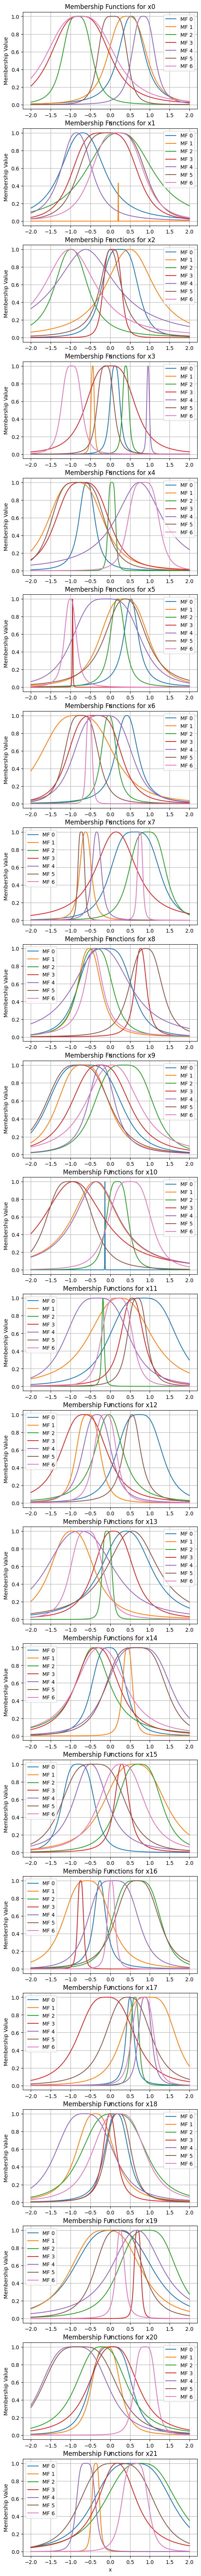

In [97]:
model.plot_premises(group_by_dim=True)